# PSet 2 — Problem 1: Interpolation and Occupational Choice

This notebook solves **Problem 1** of the problem set. The goal is to **compare approximation methods** (Chebyshev polynomials, linear splines, cubic splines) and to use them in an **occupational-choice** setting where households choose between working for a wage or running a firm.

---

## What we do in this notebook

1. **1D interpolation**  
   We approximate three benchmark functions on $[0,1]$ (a steep exponential, a kinked function, and an oscillatory one) using Chebyshev, linear spline, and cubic spline. We report max and mean approximation errors on a fine grid so we can see how each method behaves on smooth vs difficult functions.

2. **Problem 1.2 — Occupational choice and 3D approximation**  
   Households have assets $a$, labor ability $e$, and entrepreneurial ability $z$. They choose each period whether to work (income $We$) or to be an entrepreneur (profits from a technology with collateral constraint $k \leq \lambda a$). The **value of the best occupation** is $V(a,e,z)$. We approximate $V$ on a 3D tensor grid using the same three methods (Chebyshev, linear spline, cubic spline) and compare errors. Here the grid is *imposed* (not Chebyshev nodes), so the Vandermonde matrix in the Chebyshev fit can be ill-conditioned as $n$ grows; splines remain stable.

3. **Extension — Dynamic economy**  
   We add a **savings/consumption** decision: households maximize lifetime utility subject to the budget constraint, using **value function iteration** with continuation values **interpolated on the asset grid**. We then compute the **stationary distribution** of wealth via forward iteration (with lottery weights for off-grid savings). The result is policy functions, occupational choice maps, and wealth concentration statistics (Lorenz curve, top shares, tail).

---

The code uses `hetmacro` for interpolation, grids, Markov chains, and lottery weights; benchmark functions and PSet-specific grids/tables are defined in the notebook.

Import Packages

In [8]:
import sys
from pathlib import Path
import pandas as pd
from scipy.interpolate import RegularGridInterpolator
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 2) General tools (reusable)
# ------------------------------------------------------------
ROOT = Path.cwd().resolve().parent
TEX_DIR = ROOT / "tex"
TEX_DIR.mkdir(exist_ok=True)

# Robust repo-root detection from current working directory.
HET_REPO = None
for p in [ROOT, *ROOT.parents]:
    if (p / "hetmacro").exists():
        HET_REPO = p
        break
if HET_REPO is None:
    raise RuntimeError("Could not locate repository root containing 'hetmacro'.")
if str(HET_REPO) not in sys.path:
    sys.path.append(str(HET_REPO))

from hetmacro.interpolation import cheb_nodes, cheb_basis, spline_fit, spline_eval
from hetmacro.grids import gridmake, make_grid_1d
from hetmacro.markov import rouwenhorst, stationary_distribution as mc_stationary
from hetmacro.interpolation import get_lottery


def summarize_errors(truth, approx):
    err = np.abs(approx - truth)
    return float(err.max()), float(err.mean())


print("ROOT:", ROOT)
print("HET_REPO:", HET_REPO)

ROOT: /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions
HET_REPO exists: True


In [2]:
# ------------------------------------------------------------
# 1) Benchmark functions 
# ------------------------------------------------------------
def f1(s):
    return np.exp(-s / 0.01)

def f2(s):
    return np.maximum(s, 0.5)

def f3(s):
    return np.sin(25 * s**2) + 0.5 * np.log(0.01 + s)

benchmark_functions = {
    "f1": f1,
    "f2": f2,
    "f3": f3,
}

print("Defined benchmark functions:", list(benchmark_functions.keys()))

Defined benchmark functions: ['f1', 'f2', 'f3']


In [3]:
# ------------------------------------------------------------
# 3) Problem 1.1 specific block: 1D interpolation exercise
# ------------------------------------------------------------
methods = ["cheb", "lin", "spli"]
ns = [21, 51, 101, 501]
smin, smax = 0.0, 1.0
s_fine = np.linspace(smin, smax, 2000)

rows_1d = []
for fname, f in benchmark_functions.items():
    truth = f(s_fine)
    for method in methods:
        for n in ns:
            if method == "cheb":
                # Calculating nodes and basis functions at the nodes (cheb_basis rescales [smin,smax] -> [-1,1] internally)
                nodes = np.sort(cheb_nodes(n, smin, smax))
                Phi = cheb_basis(nodes, n, smin, smax)
                # solving for the linear system
                c, *_ = np.linalg.lstsq(Phi, f(nodes), rcond=None) 
                # evaluating the approximation at the fine grid
                approx = cheb_basis(s_fine, n, smin, smax) @ c
            elif method == "lin":
                nodes = np.linspace(smin, smax, n)
                model = spline_fit(nodes, f(nodes), method="linear", extrapolate=True)
                approx = spline_eval(model, s_fine)
            else:
                nodes = np.linspace(smin, smax, n)
                model = spline_fit(nodes, f(nodes), method="cubic", bc_type="natural", extrapolate=True)
                approx = spline_eval(model, s_fine)

            max_err, mean_err = summarize_errors(truth, approx)
            rows_1d.append({
                "function": fname,
                "method": method,
                "n": n,
                "max_abs_err": max_err,
                "mean_abs_err": mean_err,
            })

df_1d = pd.DataFrame(rows_1d).sort_values(["function", "method", "n"])
df_1d.head(12)

,function,method,n,max_abs_err,mean_abs_err
0,f1,cheb,21,6.332178e-03,6.186344e-04
1,f1,cheb,51,6.500356e-12,1.579975e-12
2,f1,cheb,101,4.329870e-15,8.021629e-16
3,f1,cheb,501,6.133982e-15,1.344678e-15
4,f1,lin,21,4.802622e-01,1.532955e-02
5,f1,lin,51,2.051004e-01,3.126825e-03
6,f1,lin,101,7.791882e-02,8.173953e-04
7,f1,lin,501,4.527882e-03,3.133274e-05
8,f1,spli,21,4.072932e-01,1.512442e-02
9,f1,spli,51,1.414095e-01,2.381378e-03


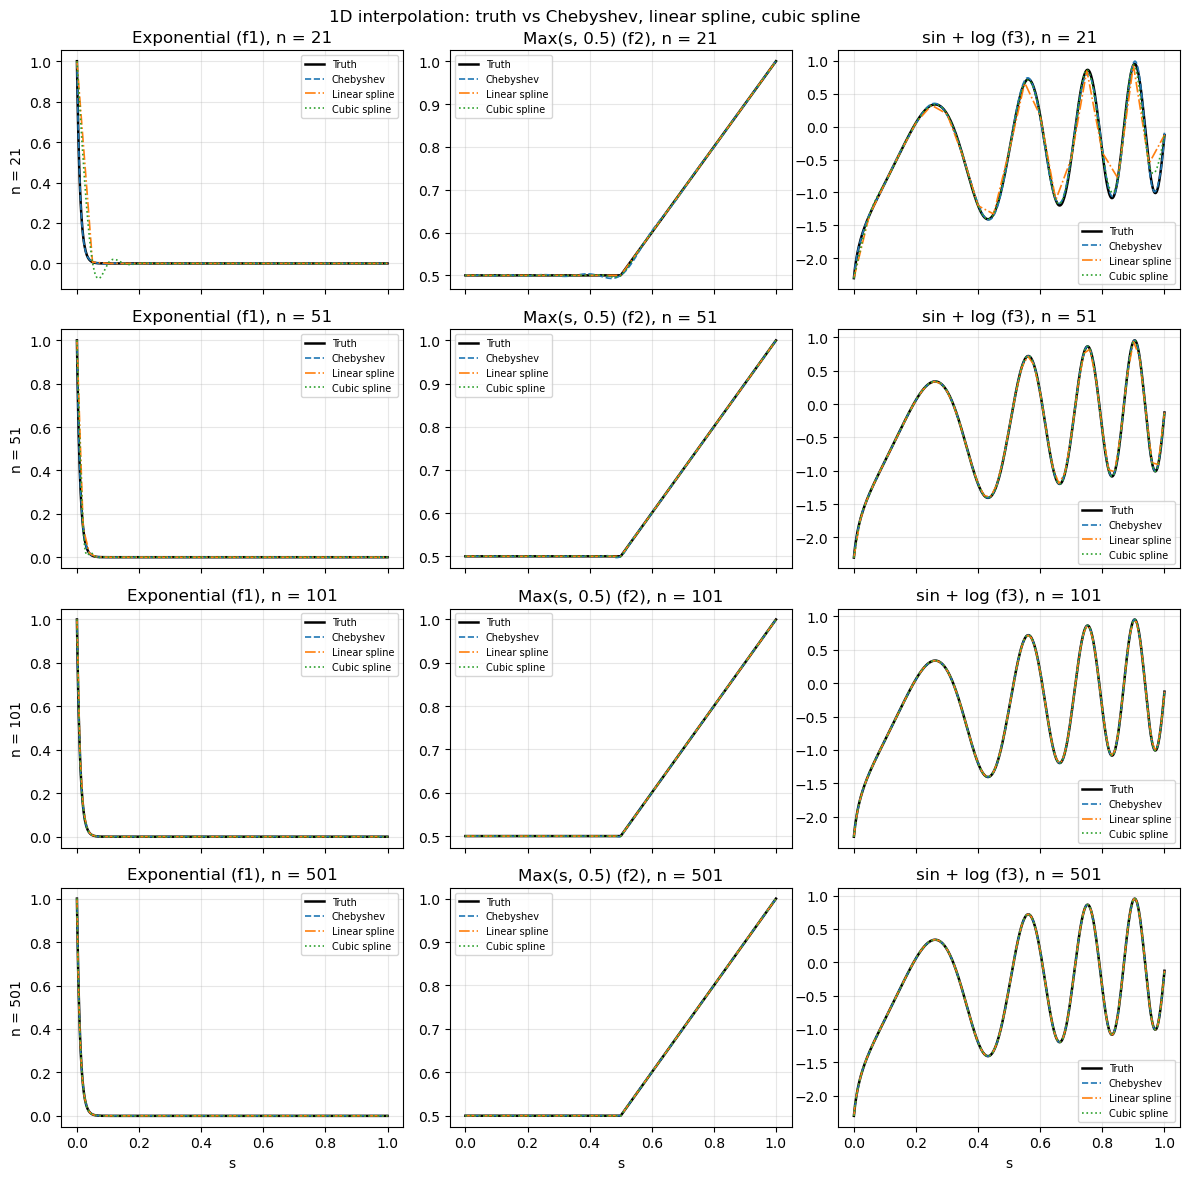

In [ ]:
# ------------------------------------------------------------
# 4×3 figure: each ROW = n (21, 51, 101, 501), each COLUMN = function (f1, f2, f3)
# In each subplot: truth + Chebyshev + linear spline + cubic spline
# ------------------------------------------------------------


ns_fig = [21, 51, 101, 501]
smin, smax = 0.0, 1.0
s_fine = np.linspace(smin, smax, 500)

func_names = ["f1", "f2", "f3"]
func_labels = ["Exponential (f1)", "Max(s, 0.5) (f2)", "sin + log (f3)"]

fig, axes = plt.subplots(4, 3, figsize=(12, 12), sharex=True)
fig.suptitle("1D interpolation: truth vs Chebyshev, linear spline, cubic spline", fontsize=12)

for i, n in enumerate(ns_fig):
    for j, (fname, flabel) in enumerate(zip(func_names, func_labels)):
        f = benchmark_functions[fname]
        truth = f(s_fine)
        ax = axes[i, j]

        ax.plot(s_fine, truth, "k-", lw=1.8, label="Truth")

        nodes_cheb = np.sort(cheb_nodes(n, smin, smax))
        # cheb_basis rescales [smin,smax] -> [-1,1] internally
        Phi = cheb_basis(nodes_cheb, n, smin, smax)
        c, *_ = np.linalg.lstsq(Phi, f(nodes_cheb), rcond=None)
        approx_cheb = cheb_basis(s_fine, n, smin, smax) @ c
        ax.plot(s_fine, approx_cheb, "C0--", lw=1.2, label="Chebyshev")

        nodes_lin = np.linspace(smin, smax, n)
        model_lin = spline_fit(nodes_lin, f(nodes_lin), method="linear", extrapolate=True)
        approx_lin = spline_eval(model_lin, s_fine)
        ax.plot(s_fine, approx_lin, "C1-.", lw=1.2, label="Linear spline")

        model_cub = spline_fit(nodes_lin, f(nodes_lin), method="cubic", bc_type="natural", extrapolate=True)
        approx_cub = spline_eval(model_cub, s_fine)
        ax.plot(s_fine, approx_cub, "C2:", lw=1.2, label="Cubic spline")

        ax.set_title(f"{flabel}, n = {n}")
        ax.legend(loc="best", fontsize=7)
        ax.grid(True, alpha=0.3)
    axes[i, 0].set_ylabel(f"n = {n}")

for j in range(3):
    axes[-1, j].set_xlabel("s")

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_problem1_1d_interpolation.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem1_1d_interpolation.png", dpi=200, bbox_inches="tight")
plt.show()

In [5]:
# ------------------------------------------------------------
# 4) Problem 1.2 specific block: 3D interpolation exercise
# ------------------------------------------------------------
# Quick test: one method, one small n (set False for full run)
QUICK_TEST = False
if QUICK_TEST:
    methods_3d = ["spli"]
    n_list_3d = [5]
else:
    methods_3d = methods
    n_list_3d = [11, 15, 21]

# set the parametrization of the problem
alpha, eta, W, R, lamb = 1/3, 0.85, 1.0, 0.10, 2.0

def income_3d(points):
    '''
    This function computes the income of a household given its assets, entrepreneurial ability, and labor-market ability.
    It is used to evaluate the true income function in the 3D interpolation exercise.
    '''
    # Grid values
    a = points[:, 0]
    z = points[:, 1]
    e = points[:, 2]

    # Compute the unconstrained optimal capital choice
    kst = (
        (alpha * eta / R) ** ((1.0 - (1.0 - alpha) * eta) / (1.0 - eta))
        * (((1.0 - alpha) * eta) / W) ** (((1.0 - alpha) * eta) / (1.0 - eta))
        * z ** (1.0 / (1.0 - eta))
    )

    # Compute the constrained optimal capital choice
    k = np.minimum(kst, lamb * a)

    # Compute the optimal profits
    c0 = 1.0 - (1.0 - alpha) * eta
    c1 = (((1.0 - alpha) * eta) / W) ** (((1.0 - alpha) * eta) / c0)
    pi = c0 * c1 * z ** (1.0 / c0) * k ** ((alpha * eta) / c0) - R * k
    y = np.maximum(pi, W * e)
    return y

rows_3d = []
print("3D interpolation run" + (" (QUICK_TEST: 1 method, small n)" if QUICK_TEST else " (full)"))
for method in methods_3d:
    for n in n_list_3d:
        print(f"  [method={method}, n={n}]")
        print("    Building 1D grids (agrid, zgrid, egrid)...")
        agrid = make_grid_1d(0.0, 50.0, n, spacing="linear")
        zgrid = make_grid_1d(1.0, 5.0, n, spacing="linear")
        egrid = make_grid_1d(1.0, 5.0, n, spacing="linear")

        print("    Building nodes and evaluating V on grid...")
        nodes = gridmake(agrid, zgrid, egrid)
        v_nodes = income_3d(nodes).reshape(n, n, n)

        if method == "cheb":
            # Tensor-product Chebyshev fit in 3D (problem-specific implementation)
            def to_cube(pts, agrid, zgrid, egrid):
                """Map (a,z,e) from grid bounds to [-1,1]^3 for chebvander3d."""
                a = 2.0 * (pts[:, 0] - agrid.min()) / (agrid.max() - agrid.min()) - 1.0
                z = 2.0 * (pts[:, 1] - zgrid.min()) / (zgrid.max() - zgrid.min()) - 1.0
                e = 2.0 * (pts[:, 2] - egrid.min()) / (egrid.max() - egrid.min()) - 1.0
                return a, z, e

            # find the coefs of the chebyshev approximation
            print("    Fitting Chebyshev (Vandermonde + lstsq)...")
            aa, zz, ee = to_cube(nodes, agrid, zgrid, egrid)
            V = np.polynomial.chebyshev.chebvander3d(aa, zz, ee, [n - 1, n - 1, n - 1])
            coef, *_ = np.linalg.lstsq(V, v_nodes.ravel(), rcond=None)

            # define the approximation function
            def approx_fn(x):
                ax, zx, ex = to_cube(x, agrid, zgrid, egrid)
                VX = np.polynomial.chebyshev.chebvander3d(ax, zx, ex, [n - 1, n - 1, n - 1])
                return VX @ coef
        else:
            # Use explicit spline methods on the regular grid:
            # - "slinear": tensor-product linear spline (k=1)
            # - "cubic":   tensor-product cubic spline (k=3)
            interp_method = "slinear" if method == "lin" else "cubic"
            print(f"    Building RegularGridInterpolator (method={interp_method})...")
            rgi = RegularGridInterpolator((agrid, zgrid, egrid), v_nodes, method=interp_method, bounds_error=False, fill_value=None)

            def approx_fn(x):
                return rgi(x)

        print("    Building fine grid and evaluating truth + approx...")
        nf = 3 * n
        af = make_grid_1d(0.0, 50.0, nf, spacing="linear")
        zf = make_grid_1d(1.0, 5.0, nf, spacing="linear")
        ef = make_grid_1d(1.0, 5.0, nf, spacing="linear")
        fine = gridmake(af, zf, ef)

        truth = income_3d(fine)
        approx = approx_fn(fine)
        max_err, mean_err = summarize_errors(truth, approx)
        print(f"    Done. max_abs_err={max_err:.2e}, mean_abs_err={mean_err:.2e}")
        rows_3d.append({
            "method": method,
            "n": n,
            "max_abs_err": max_err,
            "mean_abs_err": mean_err,
        })

df_3d = pd.DataFrame(rows_3d).sort_values(["method", "n"])

# Save outputs for report
# (df_1d).to_csv(TEX_DIR / "problem1_1d_errors.csv", index=False)
# (df_3d).to_csv(TEX_DIR / "problem1_3d_errors.csv", index=False)

# print("Saved CSV tables to", TEX_DIR)
# print("\n1D sample:")
# display(df_1d.head())
# print("\n3D sample:")
# display(df_3d)

3D interpolation run (full)
  [method=cheb, n=11]
    Building 1D grids (agrid, zgrid, egrid)...
    Building nodes and evaluating V on grid...
    Fitting Chebyshev (Vandermonde + lstsq)...
    Building fine grid and evaluating truth + approx...
    Done. max_abs_err=8.52e+00, mean_abs_err=1.35e-01
  [method=cheb, n=15]
    Building 1D grids (agrid, zgrid, egrid)...
    Building nodes and evaluating V on grid...
    Fitting Chebyshev (Vandermonde + lstsq)...
    Building fine grid and evaluating truth + approx...
    Done. max_abs_err=1.66e+02, mean_abs_err=2.01e-01
  [method=cheb, n=21]
    Building 1D grids (agrid, zgrid, egrid)...
    Building nodes and evaluating V on grid...
    Fitting Chebyshev (Vandermonde + lstsq)...
    Building fine grid and evaluating truth + approx...
    Done. max_abs_err=6.39e+05, mean_abs_err=5.31e+01
  [method=lin, n=11]
    Building 1D grids (agrid, zgrid, egrid)...
    Building nodes and evaluating V on grid...
    Building RegularGridInterpolator (

## Extension: dynamic occupational choice with VFI

This block solves the intertemporal problem
\begin{align*}
J(a,e,z)=\max_{a'\ge 0}\left\{u\big((1+r)a+V(a,e,z)-a'\big)+\beta\,\mathbb E\left[J(a',e',z')\mid e,z\right]\right\}
\end{align*}
using value function iteration (VFI).

Steps:
1. Discretize labor ability `e` and entrepreneurial ability `z` with Rouwenhorst.
2. Build the joint Markov chain for `(e,z)` via Kronecker product.
3. Solve VFI for `J`, savings policy `a'`, and consumption policy `c`.
4. Compute the stationary distribution over `(a,e,z)`.
5. Report occupational shares, wealth distribution, and policy-function plots.

In [23]:
# ------------------------------------------------------------
# 5) Extension setup: Markov processes and grids
# ------------------------------------------------------------

# Preferences and returns
beta = 0.95
gamma = 2.0
r = 0.02

# Ability process parameters (independent AR(1) in logs)
n_e, rho_e, sigma_e = 5, 0.90, 0.20
n_z, rho_z, sigma_z = 5, 0.90, 0.30

# Asset grid for dynamic problem (note: VFI here is O(n_a^2), so keep n_a moderate)
n_a = 120
A_MAX_SOLVE = 200.0  # increase to avoid artificial top-grid cap in a' policy
A_MAX_PLOT = 60.0    # truncate x-axis in plots for readability (tail is near-linear)
a_grid = make_grid_1d(0.0, A_MAX_SOLVE, n_a, spacing="power", power=2.0)

print("Building Rouwenhorst chains...")
e_log, Pi_e = rouwenhorst(n_e, rho_e, sigma_e)
z_log, Pi_z = rouwenhorst(n_z, rho_z, sigma_z)

# Convert to levels and normalize means to one under each marginal stationary distribution
pi_e = mc_stationary(Pi_e, method="iterate")
pi_z = mc_stationary(Pi_z, method="iterate")
e_states = np.exp(e_log)
z_states = np.exp(z_log)
e_states = e_states / np.dot(pi_e, e_states)
z_states = z_states / np.dot(pi_z, z_states)

# Joint chain for independent processes: state index s = ie * n_z + iz
Pi_joint = np.kron(Pi_e, Pi_z)
pi_joint = mc_stationary(Pi_joint, method="iterate")
n_s = n_e * n_z

print(f"n_e={n_e}, n_z={n_z}, n_s={n_s}, n_a={n_a}")
print("Row sums Pi_joint (min/max):", Pi_joint.sum(axis=1).min(), Pi_joint.sum(axis=1).max())

# Precompute static occupational-choice income V(a,e,z) for each discrete state
print("Precomputing V(a,e,z) on (state, asset) grid...")
y = np.empty((n_s, n_a))
pi_oper = np.empty((n_s, n_a))
occ = np.zeros((n_s, n_a), dtype=float)

for ie, e_val in enumerate(e_states):
    for iz, z_val in enumerate(z_states):
        s = ie * n_z + iz
        pts = np.column_stack([
            a_grid,
            np.full(n_a, z_val),
            np.full(n_a, e_val),
        ])
        y_s = income_3d(pts)
        y[s, :] = y_s

        # Entrepreneurial profits only (before max with worker wage)
        a = a_grid
        kst = (
            (alpha * eta / R) ** ((1.0 - (1.0 - alpha) * eta) / (1.0 - eta))
            * (((1.0 - alpha) * eta) / W) ** (((1.0 - alpha) * eta) / (1.0 - eta))
            * z_val ** (1.0 / (1.0 - eta))
        )
        k = np.minimum(kst, lamb * a)
        c0 = 1.0 - (1.0 - alpha) * eta
        c1 = (((1.0 - alpha) * eta) / W) ** (((1.0 - alpha) * eta) / c0)
        pi_s = c0 * c1 * z_val ** (1.0 / c0) * k ** ((alpha * eta) / c0) - R * k
        pi_oper[s, :] = pi_s
        occ[s, :] = (pi_s > W * e_val).astype(float)

print("Setup complete.")

Building Rouwenhorst chains...
n_e=5, n_z=5, n_s=25, n_a=120
Row sums Pi_joint (min/max): 1.0 1.0000000000000004
Precomputing V(a,e,z) on (state, asset) grid...
Setup complete.


In [24]:
# ------------------------------------------------------------
# 6) Extension core: Value Function Iteration (VFI)
# ------------------------------------------------------------
def crra_utility(c, gamma):
    if gamma == 1.0:
        return np.log(c)
    return c ** (1.0 - gamma) / (1.0 - gamma)


def run_vfi(Pi_joint, a_grid, y, beta, r, gamma, tol=1e-6, max_iter=500, n_a_prime=None):
    """VFI with 1D interpolation of continuation value in a'.

    We still keep states on (s, a_grid), but allow choices a' on a refined
    grid (a'_grid) that is denser than a_grid.
    """
    n_s, n_a = y.shape
    V = np.zeros((n_s, n_a))

    # Choice grid for a' (finer + curvature-aligned to reduce jagged policies)
    if n_a_prime is None:
        n_a_prime = 4 * n_a - 3
    a_prime_dense = make_grid_1d(float(a_grid[0]), float(a_grid[-1]), int(n_a_prime), spacing="power", power=2.0)
    # Include original state nodes exactly in the choice set for consistency
    a_prime_grid = np.unique(np.concatenate([a_grid, a_prime_dense]))

    # Store optimal policy in levels (continuous-like), and nearest index for diagnostics
    a_pol = np.zeros((n_s, n_a))
    a_idx = np.zeros((n_s, n_a), dtype=np.int32)

    for it in range(max_iter):
        EV = Pi_joint @ V
        V_new = np.empty_like(V)

        for s in range(n_s):
            # Continuation value as function of a': interpolate from state grid to choice grid
            cont_on_ap = np.interp(a_prime_grid, a_grid, beta * EV[s, :])
            coh = (1.0 + r) * a_grid + y[s, :]

            for ia in range(n_a):
                # Feasible set: 0 <= a' <= coh
                feasible = a_prime_grid <= (coh[ia] - 1e-12)
                if not np.any(feasible):
                    # Safety fallback (should be rare with positive income)
                    a_star = a_prime_grid[0]
                    c_star = max(coh[ia] - a_star, 1e-12)
                    V_new[s, ia] = crra_utility(np.array([c_star]), gamma)[0] + cont_on_ap[0]
                    a_pol[s, ia] = a_star
                    a_idx[s, ia] = 0
                    continue

                ap = a_prime_grid[feasible]
                c = coh[ia] - ap
                u = np.where(c > 1e-12, crra_utility(c, gamma), -1e18)
                val = u + cont_on_ap[feasible]
                jloc = int(np.argmax(val))

                V_new[s, ia] = val[jloc]
                a_pol[s, ia] = ap[jloc]

                # Keep nearest index on state grid for diagnostics only
                a_idx[s, ia] = int(np.searchsorted(a_grid, a_pol[s, ia], side="left").clip(0, n_a - 1))

        diff = np.max(np.abs(V_new - V))
        if it % 10 == 0 or diff < tol:
            print(f"VFI iter={it:4d}, sup norm diff={diff:.3e}")

        V = V_new
        if diff < tol:
            break

    c_pol = (1.0 + r) * a_grid[np.newaxis, :] + y - a_pol
    return V, a_pol, c_pol, a_idx


print("Running VFI (1D interpolation in a' continuation value)...")
V_dyn, a_policy, c_policy, a_policy_idx = run_vfi(
    Pi_joint=Pi_joint,
    a_grid=a_grid,
    y=y,
    beta=beta,
    r=r,
    gamma=gamma,
    tol=1e-6,
    max_iter=400,
    n_a_prime=4 * n_a - 3,
)
print("VFI finished.")
print("Consumption min/max:", c_policy.min(), c_policy.max())
print("Savings min/max:", a_policy.min(), a_policy.max())

# Diagnostics: how often is the upper asset bound binding?
share_at_top = float(np.mean(a_policy >= (a_grid[-1] - 1e-10)))
print(f"Share of (state,a) points choosing a' at upper bound: {share_at_top:.3%}")


Running VFI (1D interpolation in a' continuation value)...
VFI iter=   0, sup norm diff=2.779e+00
VFI iter=  10, sup norm diff=9.920e-01
VFI iter=  20, sup norm diff=4.659e-01
VFI iter=  30, sup norm diff=2.395e-01
VFI iter=  40, sup norm diff=1.273e-01
VFI iter=  50, sup norm diff=6.925e-02
VFI iter=  60, sup norm diff=3.837e-02
VFI iter=  70, sup norm diff=2.158e-02
VFI iter=  80, sup norm diff=1.229e-02
VFI iter=  90, sup norm diff=7.061e-03
VFI iter= 100, sup norm diff=4.090e-03
VFI iter= 110, sup norm diff=2.385e-03
VFI iter= 120, sup norm diff=1.399e-03
VFI iter= 130, sup norm diff=8.242e-04
VFI iter= 140, sup norm diff=4.875e-04
VFI iter= 150, sup norm diff=2.892e-04
VFI iter= 160, sup norm diff=1.719e-04
VFI iter= 170, sup norm diff=1.024e-04
VFI iter= 180, sup norm diff=6.107e-05
VFI iter= 190, sup norm diff=3.646e-05
VFI iter= 200, sup norm diff=2.178e-05
VFI iter= 210, sup norm diff=1.302e-05
VFI iter= 220, sup norm diff=7.786e-06
VFI iter= 230, sup norm diff=4.658e-06
VFI i

In [25]:
# ------------------------------------------------------------
# 7) Stationary distribution over (a,e,z)
# ------------------------------------------------------------

def stationary_distribution_joint(Pi_joint, a_policy, a_grid, tol=1e-10, max_iter=20_000):
    n_s, n_a = a_policy.shape
    a_i, a_pi = get_lottery(a_policy, a_grid)

    D = np.outer(pi_joint, np.ones(n_a) / n_a)

    for it in range(max_iter):
        D_end = np.zeros_like(D)

        for s in range(n_s):
            for ia in range(n_a):
                i = a_i[s, ia]
                w = a_pi[s, ia]
                mass = D[s, ia]
                D_end[s, i] += w * mass
                D_end[s, i + 1] += (1.0 - w) * mass

        D_new = Pi_joint.T @ D_end
        diff = np.max(np.abs(D_new - D))

        if it % 50 == 0 or diff < tol:
            print(f"Stationary iter={it:5d}, sup norm diff={diff:.3e}")

        D = D_new
        if diff < tol:
            break

    return D


print("Computing stationary distribution...")
D_joint = stationary_distribution_joint(Pi_joint, a_policy, a_grid)
print("Stationary distribution done.")
print("Mass check:", D_joint.sum())

# Main aggregates
wealth_marginal = D_joint.sum(axis=0)
assets_mean = np.dot(wealth_marginal, a_grid)
entrepreneur_share = np.sum(D_joint * occ)

print(f"Mean assets: {assets_mean:.4f}")
print(f"Entrepreneur share: {entrepreneur_share:.4f}")

Computing stationary distribution...
Stationary iter=    0, sup norm diff=3.225e-03
Stationary iter=   50, sup norm diff=6.325e-05
Stationary iter=  100, sup norm diff=1.483e-05
Stationary iter=  150, sup norm diff=2.330e-06
Stationary iter=  200, sup norm diff=5.506e-07
Stationary iter=  250, sup norm diff=1.279e-07
Stationary iter=  300, sup norm diff=2.949e-08
Stationary iter=  350, sup norm diff=6.810e-09
Stationary iter=  400, sup norm diff=1.573e-09
Stationary iter=  450, sup norm diff=3.631e-10
Stationary iter=  494, sup norm diff=9.998e-11
Stationary distribution done.
Mass check: 1.0000000000001845
Mean assets: 51.3774
Entrepreneur share: 0.3021


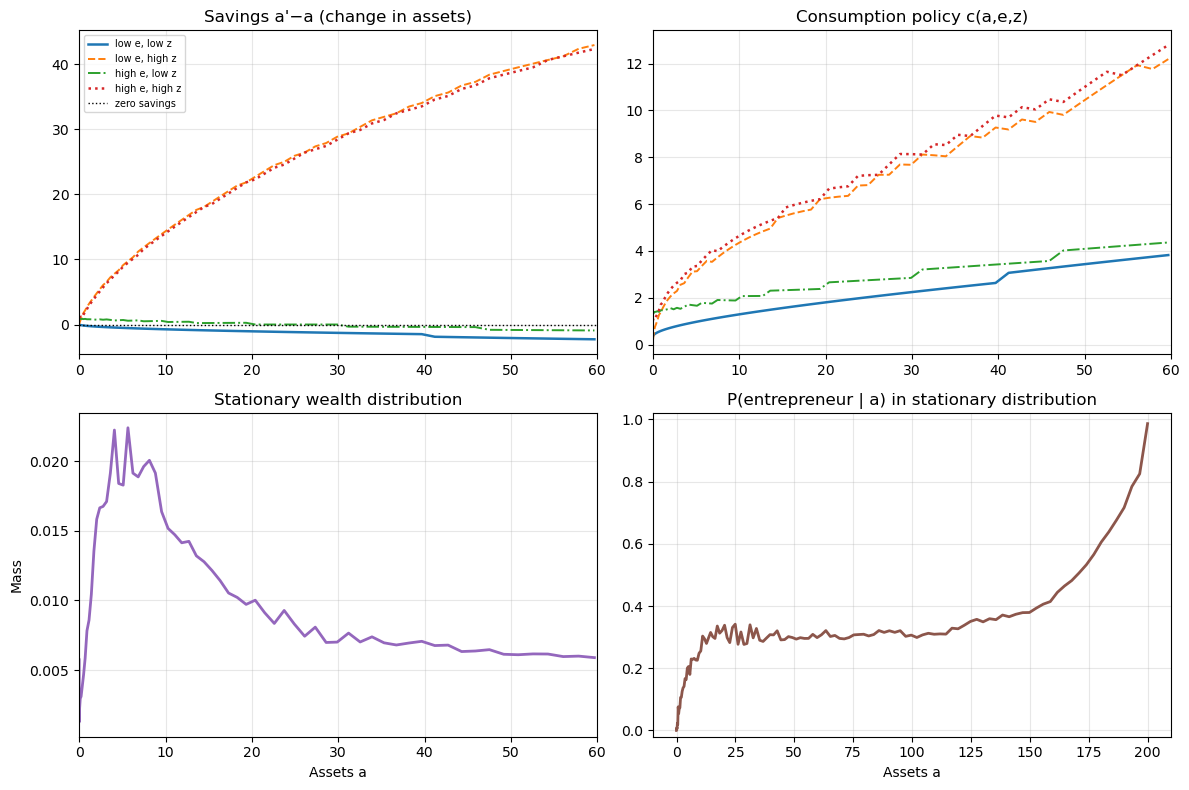

,mean_assets,entrepreneur_share,beta,gamma,r,n_a,n_e,n_z
0,51.377392,0.302122,0.95,2.0,0.02,120,5,5


iz,0,1,2,3,4
ie,,,,,
0,NaN,NaN,NaN,0.353082,0.056493
1,NaN,NaN,NaN,0.692042,0.056493
2,NaN,NaN,NaN,1.708919,0.127110
3,NaN,NaN,NaN,3.615564,0.225973
4,NaN,NaN,NaN,11.072664,0.508439


In [ ]:
# ------------------------------------------------------------
# 8) Policy/distribution analysis
# ------------------------------------------------------------
# Occupational threshold in assets: first a where entrepreneur is preferred
rows_cutoff = []
for ie, e_val in enumerate(e_states):
    for iz, z_val in enumerate(z_states):
        s = ie * n_z + iz
        idx = np.where(occ[s, :] > 0.5)[0]
        a_cut = np.nan if len(idx) == 0 else a_grid[idx[0]]
        rows_cutoff.append({
            "ie": ie,
            "iz": iz,
            "e": e_val,
            "z": z_val,
            "a_cutoff_entrepreneur": a_cut,
        })

df_cutoff = pd.DataFrame(rows_cutoff)
df_cutoff.head()

# Pick four representative states for policy plots
state_low = 0
state_high_z = n_z - 1
state_high_e = (n_e - 1) * n_z
state_high_both = n_e * n_z - 1

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

# Truncate plots to focus on the economically relevant asset range
plot_mask = a_grid <= A_MAX_PLOT
ag = a_grid[plot_mask]

# Savings = change in assets: a' - a
savings_low = (a_policy[state_low] - a_grid)[plot_mask]
savings_high_z = (a_policy[state_high_z] - a_grid)[plot_mask]
savings_high_e = (a_policy[state_high_e] - a_grid)[plot_mask]
savings_high_both = (a_policy[state_high_both] - a_grid)[plot_mask]
axes[0, 0].plot(ag, savings_low, "C0-", lw=1.8, label="low e, low z")
axes[0, 0].plot(ag, savings_high_z, "C1--", lw=1.4, label="low e, high z")
axes[0, 0].plot(ag, savings_high_e, "C2-.", lw=1.4, label="high e, low z")
axes[0, 0].plot(ag, savings_high_both, "C3:", lw=1.8, label="high e, high z")
axes[0, 0].axhline(0, color="k", linestyle=":", lw=1.0, label="zero savings")
axes[0, 0].set_title("Savings a'−a (change in assets)")
axes[0, 0].set_xlim(0.0, 60.0)
axes[0, 0].legend(fontsize=7)
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(ag, c_policy[state_low][plot_mask], "C0-", lw=1.8)
axes[0, 1].plot(ag, c_policy[state_high_z][plot_mask], "C1--", lw=1.4)
axes[0, 1].plot(ag, c_policy[state_high_e][plot_mask], "C2-.", lw=1.4)
axes[0, 1].plot(ag, c_policy[state_high_both][plot_mask], "C3:", lw=1.8)
axes[0, 1].set_title("Consumption policy c(a,e,z)")
axes[0, 1].set_xlim(0.0, 60.0)
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(ag, wealth_marginal[plot_mask], "C4-", lw=2.0)
axes[1, 0].set_title("Stationary wealth distribution")
axes[1, 0].set_xlim(0.0, A_MAX_PLOT)
axes[1, 0].set_xlabel("Assets a")
axes[1, 0].set_ylabel("Mass")
axes[1, 0].grid(alpha=0.3)

# Occupational probability by asset under stationary (integrating over e,z)
# Show full asset range here (even if other panels are truncated)
occ_by_a = (D_joint * occ).sum(axis=0) / np.maximum(wealth_marginal, 1e-14)
axes[1, 1].plot(a_grid, occ_by_a, "C5-", lw=2.0)
axes[1, 1].set_ylim(-0.02, 1.02)
axes[1, 1].set_title("P(entrepreneur | a) in stationary distribution")
axes[1, 1].set_xlabel("Assets a")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_problem1_extension_policies.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem1_extension_policies.png", dpi=200, bbox_inches="tight")
plt.show()

# Compact summary table for report
summary_ext = pd.DataFrame([
    {
        "mean_assets": assets_mean,
        "entrepreneur_share": entrepreneur_share,
        "beta": beta,
        "gamma": gamma,
        "r": r,
        "n_a": n_a,
        "n_e": n_e,
        "n_z": n_z,
    }
])

display(summary_ext)
display(df_cutoff.pivot(index="ie", columns="iz", values="a_cutoff_entrepreneur"))

# Optional save for TeX integration
# summary_ext.to_csv(TEX_DIR / "problem1_extension_summary.csv", index=False)
# df_cutoff.to_csv(TEX_DIR / "problem1_extension_cutoffs.csv", index=False)

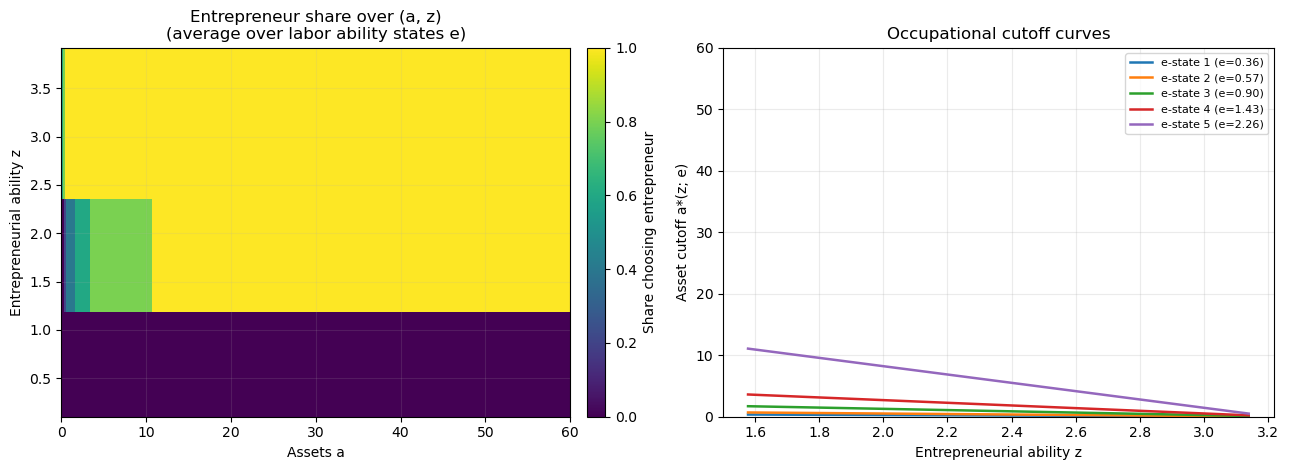

In [36]:
# ------------------------------------------------------------
# 9) Occupational-choice visualization (clean 2-panel view)
# ------------------------------------------------------------
# Panel A: entrepreneur share over (a,z), averaging over labor ability states e
# Panel B: cutoff curves a*(z; e) for each labor-ability state

occ_3d = occ.reshape(n_e, n_z, n_a)  # axes: (ie, iz, ia)

# Equal-weight average over e (visual summary of the full 3D object)
occ_share_az = occ_3d.mean(axis=0)  # shape (n_z, n_a), in [0,1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

# ----- Panel A: heatmap of entrepreneur share -----
im = axes[0].pcolormesh(
    a_grid,
    z_states,
    occ_share_az,
    shading="nearest",
    cmap="viridis",
    vmin=0.0,
    vmax=1.0,
)
axes[0].set_title("Entrepreneur share over (a, z)\n(average over labor ability states e)")
axes[0].set_xlabel("Assets a")
axes[0].set_ylabel("Entrepreneurial ability z")
axes[0].grid(alpha=0.15)

# Optional readability: zoom x-axis where transitions happen most
axes[0].set_xlim(0.0, A_MAX_PLOT)

cbar = fig.colorbar(im, ax=axes[0], fraction=0.046, pad=0.03)
cbar.set_label("Share choosing entrepreneur")

# ----- Panel B: cutoff curves a*(z; e) -----
for ie in range(n_e):
    cutoff_ie = df_cutoff[df_cutoff["ie"] == ie].sort_values("z")
    finite = np.isfinite(cutoff_ie["a_cutoff_entrepreneur"].to_numpy())
    if finite.any():
        axes[1].plot(
            cutoff_ie.loc[finite, "z"],
            cutoff_ie.loc[finite, "a_cutoff_entrepreneur"],
            lw=1.8,
            label=f"e-state {ie+1} (e={e_states[ie]:.2f})",
        )

axes[1].set_title("Occupational cutoff curves")
axes[1].set_xlabel("Entrepreneurial ability z")
axes[1].set_ylabel("Asset cutoff a*(z; e)")
axes[1].set_ylim(0.0, A_MAX_PLOT)
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8, loc="best")

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_problem1_extension_occ_map.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem1_extension_occ_map.png", dpi=200, bbox_inches="tight")
plt.show()

Wealth concentration diagnostics (stationary, from D_joint):
- Asset percentiles:
  q50 = 20.5694
  q90 = 155.7870
  q95 = 187.8496
  q99 = 199.1143
- Top wealth shares:
  top10%: 0.3620
  top5%: 0.1985
  top1%: 0.1471
  top0.1%: 0.1471
- Gini (assets): 0.6003
- Pareto tail alpha (Hill): alpha90=5.785 (xmin=155.7870), alpha95=18.722 (xmin=187.8496)


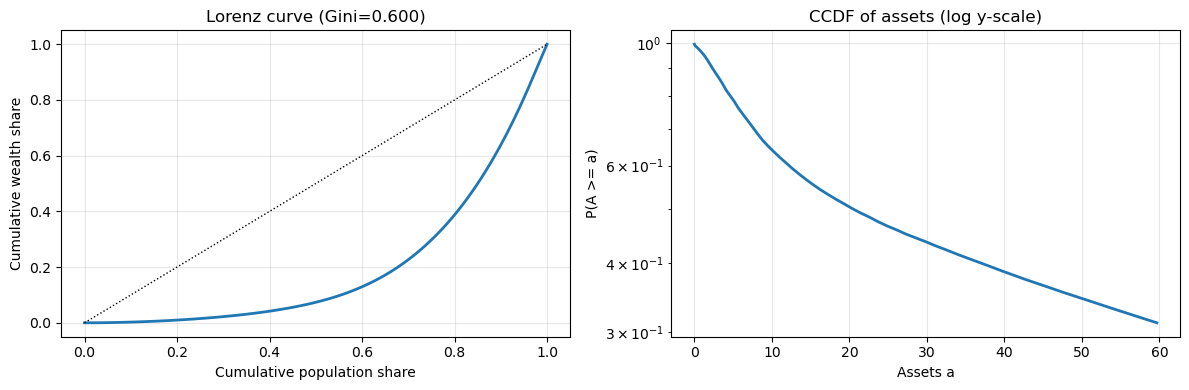

In [33]:
# ------------------------------------------------------------
# 9) Wealth concentration / Pareto tail diagnostics (stationary)
# ------------------------------------------------------------

def weighted_quantile(x, w, qs):
    """Weighted quantiles of x at probabilities qs in [0,1]."""
    x = np.asarray(x)
    w = np.asarray(w)
    qs = np.asarray(qs)
    order = np.argsort(x)
    x_s = x[order]
    w_s = w[order]
    cdf = np.cumsum(w_s)
    cdf = cdf / cdf[-1]
    return np.interp(qs, cdf, x_s)


def top_share(x, w, top_p):
    """Share of total x held by the top top_p fraction (e.g. top_p=0.01)."""
    thresh = weighted_quantile(x, w, [1.0 - top_p])[0]
    mask = x >= thresh
    num = np.sum(w[mask] * x[mask])
    den = np.sum(w * x)
    return float(num / den)


def gini_from_lorenz(x, w):
    """Weighted Gini using Lorenz curve trapezoid integration."""
    x = np.asarray(x)
    w = np.asarray(w)
    order = np.argsort(x)
    x_s = x[order]
    w_s = w[order]
    W = np.cumsum(w_s)
    W = W / W[-1]
    Y = np.cumsum(w_s * x_s)
    Y = Y / Y[-1]
    # Add (0,0) and integrate
    W2 = np.concatenate([[0.0], W])
    Y2 = np.concatenate([[0.0], Y])
    area = np.trapz(Y2, W2)
    return float(1.0 - 2.0 * area), (W2, Y2)


def hill_pareto_alpha(x, w, q_cut=0.95):
    """Weighted Hill estimator for Pareto tail exponent alpha.

    Uses x_min = weighted quantile at q_cut and tail x>=x_min.
    alpha_hat = 1 / E_w[ log(x/x_min) | x>=x_min ].
    """
    x = np.asarray(x)
    w = np.asarray(w)
    x_min = weighted_quantile(x, w, [q_cut])[0]
    mask = x >= x_min
    xt = x[mask]
    wt = w[mask]
    wt = wt / wt.sum()
    # Guard against zeros / numerical issues
    xt = np.maximum(xt, 1e-14)
    x_min = max(float(x_min), 1e-14)
    m = float(np.sum(wt * np.log(xt / x_min)))
    if m <= 0:
        return np.nan, x_min
    return float(1.0 / m), x_min


x = a_grid
w = wealth_marginal / wealth_marginal.sum()

# Percentiles (assets)
percentiles = [0.5, 0.9, 0.95, 0.99]
q_vals = weighted_quantile(x, w, percentiles)

# Top wealth shares
shares = {
    "top10%": top_share(x, w, 0.10),
    "top5%": top_share(x, w, 0.05),
    "top1%": top_share(x, w, 0.01),
    "top0.1%": top_share(x, w, 0.001),
}

# Gini + Lorenz
G, (L_pop, L_wealth) = gini_from_lorenz(x, w)

# Pareto tail exponent (Hill) at two cutoffs
alpha90, xmin90 = hill_pareto_alpha(x, w, q_cut=0.90)
alpha95, xmin95 = hill_pareto_alpha(x, w, q_cut=0.95)

print("Wealth concentration diagnostics (stationary, from D_joint):")
print("- Asset percentiles:")
for p, qv in zip(percentiles, q_vals):
    print(f"  q{int(100*p):02d} = {qv:.4f}")
print("- Top wealth shares:")
for k, v in shares.items():
    print(f"  {k}: {v:.4f}")
print(f"- Gini (assets): {G:.4f}")
print(f"- Pareto tail alpha (Hill): alpha90={alpha90:.3f} (xmin={xmin90:.4f}), alpha95={alpha95:.3f} (xmin={xmin95:.4f})")

# Plots: Lorenz curve + complementary CDF on truncated range
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(L_pop, L_wealth, lw=2.0)
ax[0].plot([0, 1], [0, 1], "k:", lw=1.0)
ax[0].set_title(f"Lorenz curve (Gini={G:.3f})")
ax[0].set_xlabel("Cumulative population share")
ax[0].set_ylabel("Cumulative wealth share")
ax[0].grid(alpha=0.3)

# CCDF: P(A >= a)
order = np.argsort(x)
x_s = x[order]
w_s = w[order]
ccdf = 1.0 - np.cumsum(w_s)
mask_plot = x_s <= A_MAX_PLOT
ax[1].plot(x_s[mask_plot], ccdf[mask_plot], lw=2.0)
ax[1].set_yscale("log")
ax[1].set_title("CCDF of assets (log y-scale)")
ax[1].set_xlabel("Assets a")
ax[1].set_ylabel("P(A >= a)")
ax[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig(TEX_DIR / "fig_problem1_extension_lorenz_ccdf.pdf", bbox_inches="tight")
fig.savefig(TEX_DIR / "fig_problem1_extension_lorenz_ccdf.png", dpi=200, bbox_inches="tight")
plt.show()

# Export tail moments for the report
moments_tail = pd.DataFrame([
    {
        "top10_share": shares["top10%"],
        "top5_share": shares["top5%"],
        "top1_share": shares["top1%"],
        "top01_share": shares["top0.1%"],
        "gini_assets": G,
        "pareto_alpha_q90": alpha90,
        "pareto_xmin_q90": xmin90,
        "pareto_alpha_q95": alpha95,
        "pareto_xmin_q95": xmin95,
    }
])

moments_tail.to_csv(TEX_DIR / "problem1_extension_tail_moments.csv", index=False)

# Quick reality-check note:
# For US data, top-1% wealth share is often ~0.3 (varies by definition/sample).
# Use this only as a rough benchmark when you compare your model moments.

In [32]:
# Save outputs for report
(df_1d).to_csv(TEX_DIR / "problem1_1d_errors.csv", index=False)
(df_3d).to_csv(TEX_DIR / "problem1_3d_errors.csv", index=False)

# Also export as LaTeX tables (escape underscores in headers for LaTeX)
def latex_header(cols):
    return [c.replace("_", r"\_") for c in cols]
(df_1d).to_latex(
    TEX_DIR / "tab_problem1_1d_errors.tex",
    index=False,
    float_format=lambda x: f"{x:.3e}",
    header=latex_header(df_1d.columns.tolist()),
)
(df_3d).to_latex(
    TEX_DIR / "tab_problem1_3d_errors.tex",
    index=False,
    float_format=lambda x: f"{x:.3e}",
    header=latex_header(df_3d.columns.tolist()),
)

print("Saved CSV + LaTeX tables to", TEX_DIR)
print("\n1D sample:")
display(df_1d.head())
print("\n3D sample:")
display(df_3d)

Saved CSV + LaTeX tables to /Users/rafaellincoln/Dropbox/Academia/Macroeconomics/Heterogeneity in Macro/Virgiliu's Course/PSets/PSet 2/My Code and Solutions/tex

1D sample:


,function,method,n,max_abs_err,mean_abs_err
0,f1,cheb,21,6.332178e-03,6.186344e-04
1,f1,cheb,51,6.500356e-12,1.579975e-12
2,f1,cheb,101,4.329870e-15,8.021629e-16
3,f1,cheb,501,6.133982e-15,1.344678e-15
4,f1,lin,21,4.802622e-01,1.532955e-02



3D sample:


,method,n,max_abs_err,mean_abs_err
0,cheb,11,8.518047,0.134949
1,cheb,15,165.749156,0.200980
2,cheb,21,638637.797248,53.139082
3,lin,11,5.217488,0.209980
4,lin,15,4.052685,0.111545
5,lin,21,3.069005,0.057287
6,spli,11,2.718309,0.083223
7,spli,15,2.066423,0.045008
8,spli,21,1.528019,0.022267
